https://automatetheboringstuff.com/3e/chapter22.html

Text recognition, more formally called optical character recognition (OCR), is the extraction of text from an image. Python has a rich collection of string methods and regular expressions for processing text, but these require you to first input the text as a string. Programs can use OCR to, for example, recognize the names on street signs and writing on checks deposited at an ATM, or to scan receipts to create electronic copies.

Like text-to-speech or speech recognition, OCR involves carrying out advanced computer science techniques, but Python modules obscure these details, making it easy to use. This chapter covers PyTesseract, the Python package that works with the open source Tesseract OCR engine. We’ll also look at the free NAPS2 application, which Python can run to apply Tesseract OCR to PDF files.



Windows
On Windows, open your browser to https://github.com/UB-Mannheim/tesseract/wiki and follow the page’s instructions to download the latest installer program. Then, double-click this installer to install Tesseract.

Tesseract recognizes English text by default. During installation, you may optionally check the checkboxes for “Additional script data (download)” and “Additional language data (download)” so that Tesseract can recognize non-English letters and languages, respectively. Installing all languages adds about 600MB to the install size. These language packs have filenames identifying the language and a .traineddata extension, such as jpn.traineddata for Japanese. Alternatively, you can check the checkboxes for individual languages to save space.

After the installation has finished, add the C:\Program Files\Tesseract-OCR folder (or whichever folder you installed Tesseract in) to the PATH environment variable so that PyTesseract can access the tesseract.exe program. Chapter 12 covered how to modify the PATH environment variable.

macOS
The Homebrew package manager can install Tesseract on macOS. Navigate to https://docs.brew.sh to install Homebrew. Install Tesseract by opening a terminal window and running brew install tesseract, then run brew install tesseract-lang to install non-English language packs.

Linux
To install Tesseract on Linux, open a terminal window and run sudo apt install tesseract-ocr. You’ll have to enter the administrator password to run this command.

To install the language packs for every language, run sudo apt install tesseract-ocr-all from the terminal. To install just the language packs you want, replace all with a three-character ISO 639 language code, such as fra for French, deu for German, or jpn for Japanese.

PyTesseract
After installing the Tesseract OCR engine, you can install the latest version of PyTesseract by following the instructions in Appendix A. PyTesseract also installs the Pillow image library.

OCR Fundamentals
Using PyTesseract and the Pillow image library, you can extract text from an image in four lines of code. You’ll need to import the PyTesseract and Pillow libraries, open the image using the Image.open() function, and then finally pass the opened image to the tess.image_to_string() function.

Let’s walk through a basic example: extracting the text from a screenshot of the introduction of my book The Big Book of Small Python Projects (No Starch Press, 2021). Download the ocr-example.png image from the book’s online resources at https://nostarch.com/automate-boring-stuff-python-3rd-edition, then enter the following into the interactive shell to open the image with Pillow and scan it with Tesseract:

In [ ]:
>>> import pytesseract as tess
>>> from PIL import Image
>>> img = Image.open('ocr-example.png')
>>> text = tess.image_to_string(img)
>>> print(text)
This book provides you with practice examples of how programming
concepts are applied, with a collection of over 80 games, simulations, and dig-
ital art programs. These aren't code snippets; they're full, runnable Python
programs. You can copy their code to become familiar with how they work,
experiment with your own changes, and then attempt to re-create them on
your own as practice. After a while, you'll start to get ideas for your own pro-
grams and, more importantly, know how to go about creating them.
--snip--

Converting text from an image file into a string requires sophisticated algorithms, but Python makes these accessible with four lines of code!

Preprocessing an Image
The text in the image from the previous section extracted almost perfectly to a Python string. However, OCR has limitations. Unlike computer- generated images such as screenshots, scanned or photographed paper can contain flaws, and photographs of real-world scenes are far too complicated to extract text from. You cannot, say, take a photo of the back of a car and expect Tesseract to extract the license plate number from it. You’d first need to crop the image around the license plate; even then, it may be unreadable. For that reason, Tesseract is intended for print documents rather than photos or handwritten text.

Even in screenshots, always consider OCR text to be imperfect and in need of correction. In particular, you might encounter issues like the following:

The string maintains any end-of-line hyphenation (for example, in “dig-” and “ital” or “pro-” and “grams”).
The string doesn’t conserve any font or size information.
The whitespace in the string may not match the text.
The string may have incorrectly scanned characters, such as confusing lowercase j and lowercase i.
If the image contains tables or multiple columns of text, the string may mix the text and include it out of order.
Pay special attention to mistakes in numbers, as they can be harder to spot than misspelled words.

Tesseract takes preprocessing steps to mitigate certain issues, but you can possibly improve its accuracy by using an image editing program to perform the following preprocessing steps:

Don’t scan multicolumn images; put each column of text into a separate image.
Use only typewritten text, not handwritten text.
Use conventional fonts, not cursive or stylized fonts.
Rotate the image so that the lines of text are perfectly upright and not skewed at a slight angle.
Use dark text on a light background, not white text on a black background.
Remove any dark borders at the edges of the image.
Add a small white border if the text runs up against the edge of the image.
Adjust the brightness and contrast of the image so that the text stands out from the background.
Remove small bits of “noise” pixels to clean up the image before scanning.
Some of these steps can be performed automatically with Python using the OpenCV library. Check out the blog post “Preprocessing Images for OCR with Python and OpenCV” at https://autbor.com/preprocessingocr for more examples.

Fixing Mistakes Using Large Language Models
The kinds of mistakes that OCR algorithms tend to make involve spacing and individual characters. Using a spellcheck algorithm won’t find OCR errors: it will point out the accurately recognized characters of words misspelled in the original image and miss errors that result in correctly spelled words. Identifying these kinds of character mistakes requires understanding context and a common sense for what the characters should be.

This is exactly the type of problem that large language model (LLM) AIs such as ChatGPT, Gemini, and LLaMA can solve. For example, consider Figure 22-1, a raw scan from Mary Shelley’s novel Frankenstein. This particular page was printed in 1831, so the paper is wrinkled and yellowed, with inconsistently inked characters. You can download frankenstein.png from the book’s online resources.

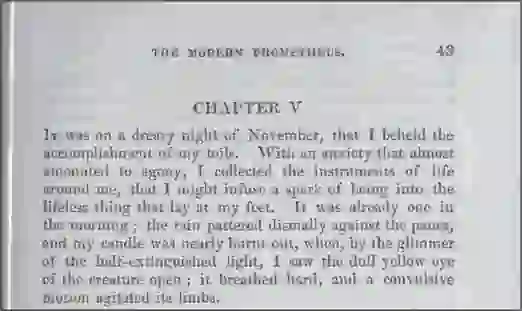

src="images/000077.webp"

Without any preprocessing, Tesseract identifies the following text:


In [ ]:
>>> import pytesseract as tess
>>> from PIL import Image
>>> img = Image.open('frankenstein.png')
>>> text = tess.image_to_string(img)
>>> print(text)
THE MODERN PROMETHEUS. 43

CHAPTER V.

Iv was on a dreary night of November, that I beheld the
accomplishment of my toils. With an anxiety that almost
amounted to agony, I collected the instruments of life
around me, that I might infuse a spark of being into the
lifeless thing that lay at my feet. It was already one in
the morning ; the rain pattered dismally against the panes,
and my candle was nearly burnt out, when, by the glimmer
of the half-extinguished light, I saw the dull yellow eye
of the creature open ; it breathed hard, and a convulsive
Motion agitated its limbs.


It does a pretty good job, but produces the incorrectly scanned characters 'Iv' instead of 'IT' at the beginning of the paragraph and 'Motion' instead of 'motion' on the last line. (The exact results may vary as the language packs are updated.)

To fix these issues, try feeding an LLM the following sample prompt and the text output of the scanned Frankenstein text:

The following is the text output from an OCR scan. Correct any spacing, missing characters, or inaccurately recognized characters from it. Do not correct spelling or grammar mistakes that exist in the original text. Put paragraphs on a single line and undo the hyphenated words that are broken across the end of a line. Only give the corrected text without explaining what OCR is or any other preface. Here is the text:

THE MODERN PROMETHEUS. 43

CHAPTER V.

Iv was on a dreary night of November, that I beheld the ...

When fed this prompt, the LLM produced this output:

THE MODERN PROMETHEUS. 43

CHAPTER V.

It was on a dreary night of November that I beheld the accomplishment of
my toils. With an anxiety that almost amounted to agony, I collected the
instruments of life around me, that I might infuse a spark of being into
the lifeless thing that lay at my feet. It was already one in the morning;
the rain pattered dismally against the panes, and my candle was nearly burnt
out, when, by the glimmer of the half-extinguished light, I saw the dull
yellow eye of the creature open; it breathed hard, and a convulsive motion
agitated its limbs.
The LLM corrected 'Iv' to 'It' and 'Motion' to 'motion'. It also removed the hyphenated words at the end of each line so that the newlines could be removed. This makes it easier to, say, copy and paste the text into a Word document or email. To automate this process, most online LLMs have APIs so that your programs can directly send prompts and receive responses. Unless you run an LLM on your local machine (which is beyond the scope of this book), you’ll have to register for these online LLM services. This may be free or require a subscription fee.

Always remember that LLMs are prone to overconfidence. You should always verify their output. The text they return may have missed some mistakes, fixed the wrong kinds of mistakes, or even introduced new mistakes of their own. You’ll still need a human to review the machine output. (And you may want a second human to review the first human’s work, as humans often make mistakes to.)

Recognizing Text in Non-English Languages
Tesseract assumes the text it is scanning is English by default, but you can specify other languages as well. “Installing Tesseract and PyTesseract” on page 528 has instructions for installing non-English language packs. You can see the language packs you have installed by entering the following into the interactive shell:

In [ ]:
>>> import pytesseract as tess
>>> tess.get_languages()
['afr', 'amh', 'ara', 'asm', 'aze', 'aze_cyrl', 'bel', 'ben', 'bod', 'bos',
--snip--
'ton', 'tur', 'uig', 'ukr', 'urd', 'uzb', 'uzb_cyrl', 'vie', 'yid', 'yor']

The strings in this list are mostly three-character ISO 639-3 language codes, with a few exceptions. For example, while 'aze' is the ISO 639-3 code for the Azeri language with Latin letters, the 'aze_cyrl' string is Azeri with Cyrillic letters. Consult the Tesseract documentation for full details.

To scan images with non-English text, pass one of these string values for the lang keyword argument. For example, frankenstein_jpn.png has a Japanese translation of a section from Frankenstein. Download this file from the book’s online resources and enter the following into the interactive shell:



In [ ]:
>>> import pytesseract as tess
>>> from PIL import Image
>>> img = Image.open('frankenstein_jpn.png')
>>> text = tess.image_to_string(img, lang='jpn')
>>> print(text)
第 5 剖 私が自分の労苦の成果を目の当たりにしたのは、11 月の芝鬱な夜でした。 ほとんど苦
痛に等しい不安を抱えながら、 私は足元に横たわる生命のないものに存在の輝きを吹き込むこ
--snip--
だ有目、 しわが寄った顔色、 そしてまっすぐな黒い大と、 より恐ろしいコントラストを形成した
だけでした。

If you use the wrong language, image_to_string() returns Tesseract’s best guess as to what English characters the Japanese characters looked like. Of course, since the characters aren’t English, the returned text will be gibberish:

In [ ]:
>>> import pytesseract as tess
>>> from PIL import Image
>>> img = Image.open('frankenstein_jpn.png')
>>> text = tess.image_to_string(img, lang='eng')
>>> print(text)
BS FABADOABOMEE AOYEVICLEDIL, 1 ADBBERKCLE, (ELA ER
WISE LW ABBA A TRA B, ALE TIRE DO EMO REVS DICED MS EKA
--snip--

To recognize text in multiple languages, you can combine language codes with a '+' character before passing it to the image_to_string() function’s lang keyword argument. For example, tess.image_to_string(img, lang='eng+jpn') recognizes both English and Japanese characters in an image.

The NAPS2 Scanner Application
While PyTesseract is useful for extracting text from images, a common use case for OCR is to create PDF documents of scanned images with searchable text. Although there are apps to do this, they often don’t offer the flexibility needed to automate the PDF generation for hundreds or thousands of images. I recommend the open source Not Another PDF Scanner 2 (NAPS2) application not just for controlling flatbed scanners but also for its ability to run Tesseract and add text to PDF documents. It is free, has straightforward features, and is available on Windows, macOS, and Linux. NAPS2 can combine several images into a PDF file with embedded text without being connected to a physical scanner. It also knows how to use Tesseract’s advanced features, so it can embed the text strings at their correct location on the PDF’s pages, and you can run it from a Python script.



Installing and Setting Up NAPS2
To install NAPS2, navigate to https://www.naps2.com/download and download the installer for your operating system. On Windows and macOS, run the downloaded installer. On Linux, download the Flatpak installer for Tesseract. Then, open a Terminal window and run flatpak install naps2-X.X.X-linux-x64.flatpak (or whatever the downloaded installer filename is) from the download folder. You may need to enter the administrator password to finish installation.

Once it’s installed, you can run the NAPS2 desktop application. On Windows, you can select NAPS2 from the Start menu. On macOS, you can run NAPS2 from Spotlight. On Linux, you’ll need to open a new terminal window and run flatpak run com.naps2.Naps2. However, this book uses NAPS2 from Python code with the subprocess module instead of the graphical user interface.

Running NAPS2 from Python
Python scripts can use the subprocess module to run the NAPS2 application with several command line arguments. When run this way, NAPS2 does not make its application window appear, which is ideal for an automation step in a Python script.

Let’s use the frankenstein.png image once again and have NAPS2 generate a PDF with embedded OCR text. The location of the NAPS2 program is different on each operating system; the following interactive shell code shows the path for Windows:

In [ ]:
>>> import subprocess
>>> naps2_path = [r'C:\Program Files\NAPS2\NAPS2.Console.exe']  # Windows
>>> proc = subprocess.run(naps2_path + ['-i', 'frankenstein.png', '-o', 
'output.pdf', '--install', 'ocr-eng', '--ocrlang', 'eng', '-n', '0', '-f', 
'-v'], capture_output=True)

On macOS, replace the line that sets the path with the following: naps2_path = ['/Applications/NAPS2.app/Contents/MacOS/NAPS2', 'console']. On Linux, use the following instead: naps2_path = ['flatpak', 'run', 'com.naps2.Naps2', 'console'].

The code creates a new file named output.pdf that contains a single page with the scanned image from frankenstein.png. However, if you open this file in a PDF application, you’ll notice that you can highlight the text and copy it to the clipboard. Many PDF applications will also let you save the PDF as a .txt text file of the OCR text.

Let’s take a look at each of the command line arguments in this example. You can change them as needed for your own purposes:

'-i', 'frankenstein.png' Sets the input as the frankenstein.png image file. See the next section, “Specifying Input,” for more information on specifying multiple inputs in various formats.

'-o', 'output.pdf' Creates a file named output.pdf to hold the OCR results.

'--install', 'ocr-eng' Installs the English language pack for OCR. This does nothing if the language is already installed. If you want to install a different language pack, use the ocr- prefix with another three-letter ISO 639 language code.

'--ocrlang', 'eng' Sets English as the language that the OCR scan recognizes. This argument is passed directly to Tesseract’s command line argument, so you could use an argument like 'eng+jpn+rus' to specify that the image has text in English, Japanese, and Russian.

'-n', '0' Specifies that you want to do zero scans and not use a flatbed scanner. This prevents error messages when there’s no physical flatbed scanner connected to your computer.

'-f' Forces NAPS2 to overwrite the output.pdf output file if a file with that name already exists.

'-v' Enables verbose mode so that status text appears as NAPS2 creates your PDF. If you want to see this status text, change the capture_output=True keyword argument for subprocess.run() to capture_output=False.

The online documentation for NAPS2’s command line arguments is at https://www.naps2.com/doc/command-line. Chapter 19 covered the subprocess module in more detail.

Specifying Input
NAPS2 lets you import PDFs and most image formats to create a final combined PDF. The application has its own mini language for specifying multiple inputs as a single command line argument following -i. This can become quite complicated, but you can think of it as semicolon delimited, with Python index and slice notation.

To specify multiple files, separate them with a semicolon. For example, passing '-i', 'cat.png;dog.png;moose.png' creates a PDF with cat.png used for the first page, dog.png used for the second page, and moose.png used for the third page.

You can also specify individual pages in a PDF with syntax that is identical to Python’s list slice syntax. Follow the PDF filename with square brackets containing the page number to use. As in Python, 0 represents the first page. For example, passing '-i', 'spam.pdf[0];spam.pdf[5];eggs.pdf' creates a PDF with page 1 of spam.pdf, followed by page 6 of spam.pdf, and then all pages of eggs.pdf.

You can specify a range of pages with this slice notation or use negative numbers to represent pages from the end of the PDF document. For example, passing '-i', 'spam.pdf[0:2];eggs.pdf[-1]' combines the first two pages of spam.pdf with the last page from eggs.pdf.

There are several more features that NAPS2 provides through its command line arguments. Check out its online documentation to learn more about them. If you find that NAPS2 isn’t suitable for your needs, I also recommend the ocrmypdf package at https://pypi.org/project/ocrmypdf/ for creating PDFs with embedded text.